In [42]:
import torch
import torch.nn.functional as F
from torch_geometric_temporal.nn.recurrent import DCRNN

from torch_geometric_temporal.dataset import ChickenpoxDatasetLoader
from torch_geometric_temporal.signal import temporal_signal_split

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from  tqdm import tqdm

Inspired from [Official documentation](https://pytorch-geometric-temporal.readthedocs.io/en/latest/notes/introduction.html)

### Load dataset

In [ ]:


loader = ChickenpoxDatasetLoader()

dataset = loader.get_dataset()

Nodes are regions, edges represent neighboring property. Weight on edges depends on distance.

Each element of dataset is a whole graph, that is 20 nodes, each having 4 features, one scalar target, and 102 edges.

Note: Values seem to already be normalized

In [9]:
next(iter(dataset))

Data(x=[20, 4], edge_index=[2, 102], edge_attr=[102], y=[20])

517


<Axes: >

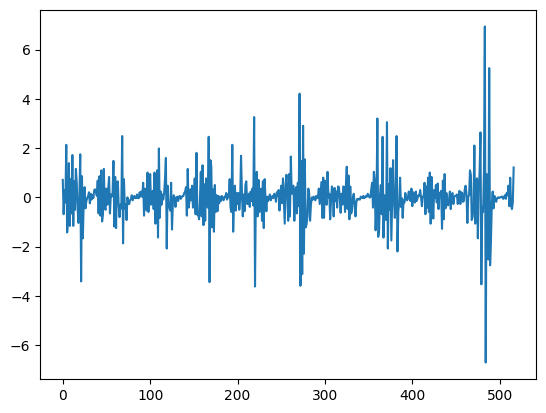

In [28]:
# Visualize number of cases in first region

values = [g.y[0].item() for g in dataset]

print(len(values))
sns.lineplot(x=range(len(values)), y=values)

### Causal train-test split

In [10]:
train_dataset, test_dataset = temporal_signal_split(dataset, train_ratio=0.8)

### Define model

Note: the final non-linearity is not integrated into the recurrent graph convolutional operation.

[List of spatio-temporal operators](https://pytorch-geometric-temporal.readthedocs.io/en/latest/modules/root.html)

[List of spatial operators](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#convolutional-layers)

In [30]:
class RecurrentGCN(torch.nn.Module):
    def __init__(self, node_features):
        super(RecurrentGCN, self).__init__()
        self.recurrent = DCRNN(node_features, 32, 1)
        self.linear = torch.nn.Linear(32, 1)

    def forward(self, x, edge_index, edge_weight):
        h = self.recurrent(x, edge_index, edge_weight)
        h = F.relu(h)
        h = self.linear(h)
        return h

### Train model

In [ ]:
model = RecurrentGCN(node_features = 4)

# Number of trainable parameters
sum(p.numel() for p in model.parameters() if p.requires_grad)

7041

In [45]:
NUM_EPOCHS = 50
lr = 1e-2
loss = np.zeros(NUM_EPOCHS)


optimizer = torch.optim.Adam(model.parameters(), lr=lr)
model.train()



for epoch in tqdm(range(NUM_EPOCHS)):
    cost = 0
    for time, snapshot in enumerate(train_dataset):
        y_hat = model(snapshot.x, snapshot.edge_index, snapshot.edge_attr)
        cost += torch.mean((y_hat.squeeze() - snapshot.y)**2) # MSE

    cost = cost / (time+1)
    loss[epoch] = cost.item()
    cost.backward()
    optimizer.step()
    optimizer.zero_grad()

100%|██████████| 50/50 [00:56<00:00,  1.12s/it]


<Axes: >

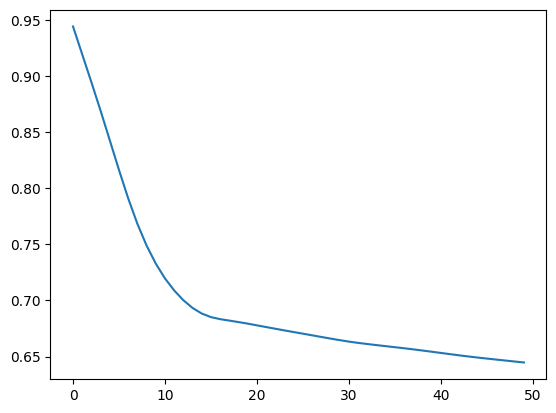

In [46]:
sns.lineplot(x=range(NUM_EPOCHS), y=loss)

### Predict and plot

In [52]:
model.eval()
predictions = []
MSE = 0.0

for time, snapshot in enumerate(test_dataset):
    y_hat = model(snapshot.x, snapshot.edge_index, snapshot.edge_attr)
    predictions.append(y_hat.detach().squeeze().numpy())
    MSE = MSE + torch.mean((y_hat.squeeze() - snapshot.y)**2)

MSE = MSE / (time+1)
MSE = MSE.item()

MSE


0.7184505462646484

In [50]:
predictions[0].shape

(20,)

<Axes: >

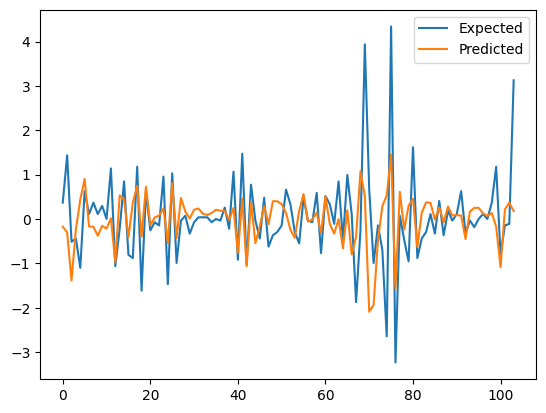

In [55]:
node_id = 10
expected = [g.y[node_id].item() for g in test_dataset]

sns.lineplot(x=range(len(expected)), y=expected, label='Expected')
sns.lineplot(x=range(len(predictions)), y=[pred[node_id] for pred in predictions], label='Predicted')